<a href="https://colab.research.google.com/github/mhawkes2/AML/blob/main/Hawkes_%26_Bloom%2C_Titanic_Machine_Learning_from_Disaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Role / Work Distribution

Primary Lead
*   EDA: Matteo
*   Feature Engineering: Matthew / Matteo
*   Preprocessing: Matthew
*   Modeling: Matthew
*   Submission & Evaluation: Matteo



# 1) Import Libraries & Datasets

In [ ]:
import numpy as np, pandas as pd, sklearn, seaborn as sns, matplotlib.pyplot as plt, xgboost
from scipy import stats

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
import joblib

sns.set(context='notebook', style='whitegrid')

test_filepath='/content/test.csv'
train_filepath='/content/train.csv'

test_df=pd.read_csv(test_filepath)
train_df=pd.read_csv(train_filepath)

# 2) Exploratory Data Analysis

TITANIC EXPLORATORY DATA ANALYSIS

Train shape: (891, 12) | Test shape: (418, 11)
Survival rate: 38.38%

Missing Values:
Age         177
Cabin       687
Embarked      2
dtype: int64


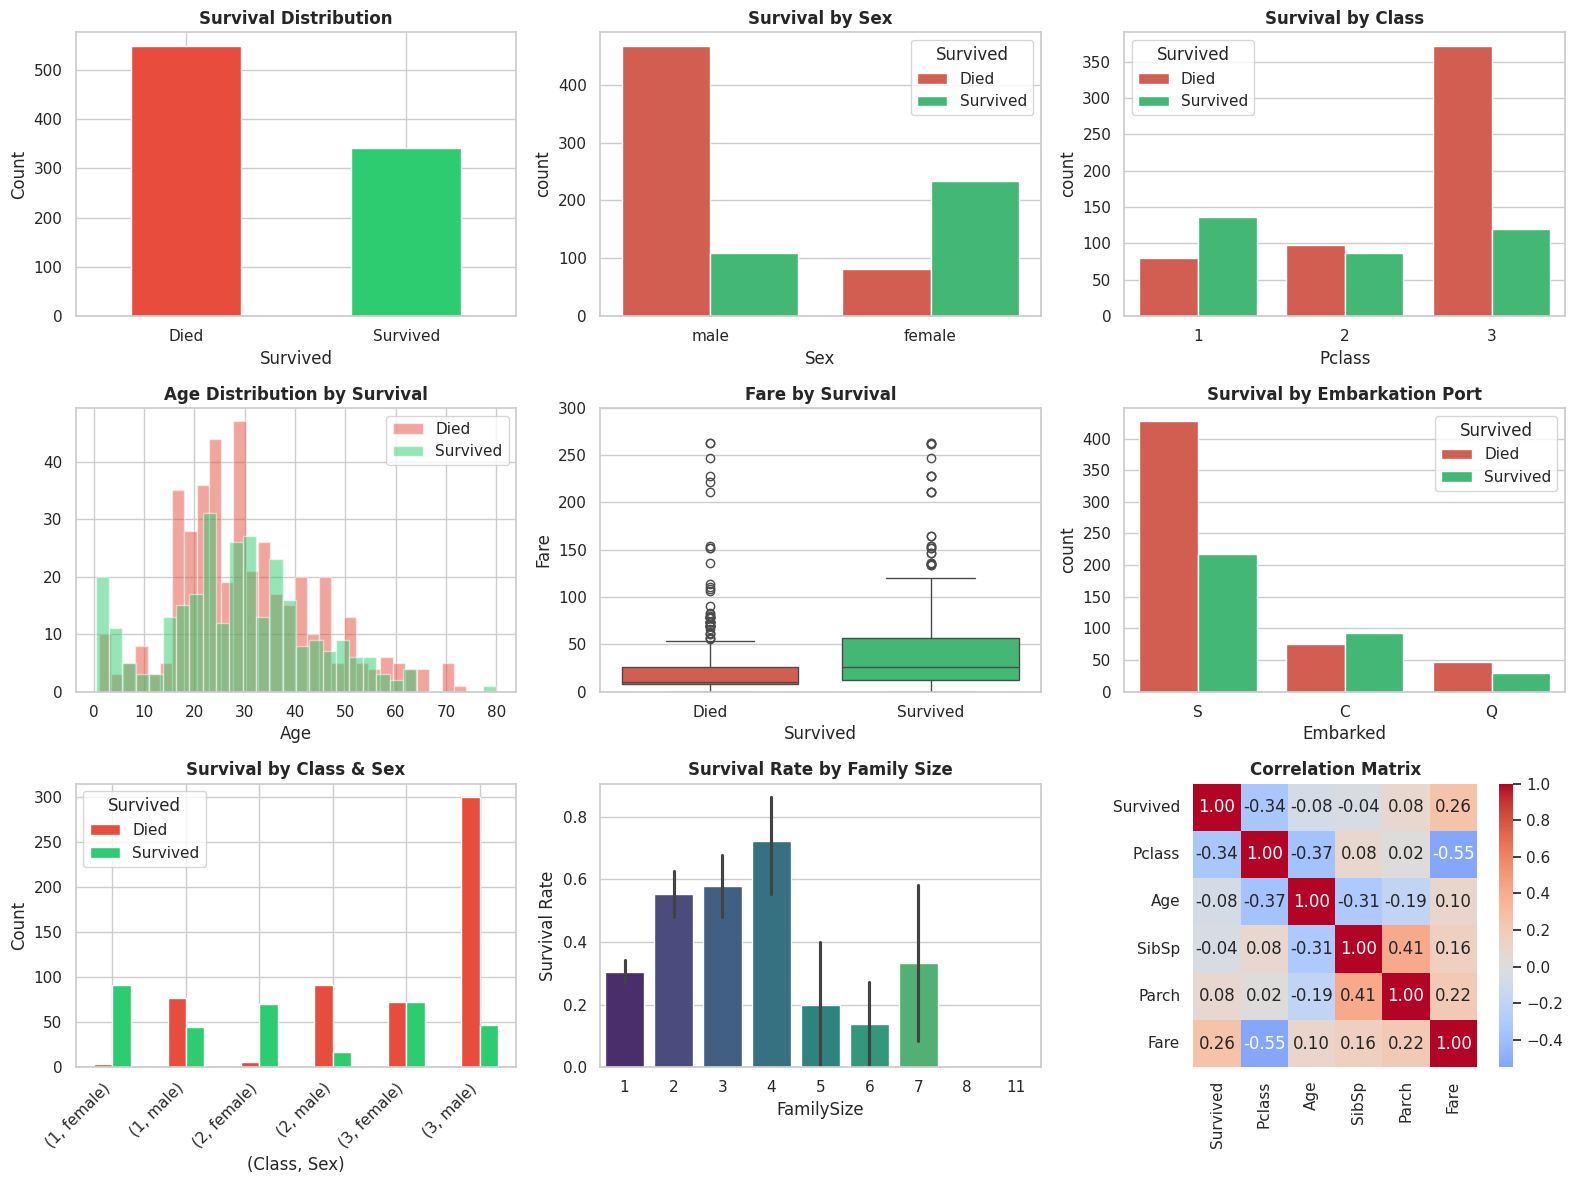


KEY STATISTICS

Survival by Sex:
            mean  count
Sex                    
female  0.742038    314
male    0.188908    577

Survival by Pclass:
            mean  count
Pclass                 
1       0.629630    216
2       0.472826    184
3       0.242363    491

Survival by Embarked:
              mean  count
Embarked                 
C         0.553571    168
Q         0.389610     77
S         0.336957    644

Key Insights:
• Women had 74% survival vs 19% for men
• 1st class: 63% survival, 3rd class: 24% survival
• Children had higher survival rates
• Small families (2-3) had better survival than large families or solo travelers


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

# Load data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("="*60)
print("TITANIC EXPLORATORY DATA ANALYSIS")
print("="*60)
print(f"\nTrain shape: {train_df.shape} | Test shape: {test_df.shape}")
print(f"Survival rate: {train_df['Survived'].mean():.2%}")

# Missing values
print("\nMissing Values:")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

# VISUALIZATIONS
fig = plt.figure(figsize=(16, 12))

# 1. Survival distribution
ax1 = plt.subplot(3, 3, 1)
train_df['Survived'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Survival Distribution', fontweight='bold')
plt.xticks([0, 1], ['Died', 'Survived'], rotation=0)
plt.ylabel('Count')

# 2. Survival by Sex
ax2 = plt.subplot(3, 3, 2)
sns.countplot(data=train_df, x='Sex', hue='Survived', palette=['#e74c3c', '#2ecc71'])
plt.title('Survival by Sex', fontweight='bold')
plt.legend(title='Survived', labels=['Died', 'Survived'])

# 3. Survival by Pclass
ax3 = plt.subplot(3, 3, 3)
sns.countplot(data=train_df, x='Pclass', hue='Survived', palette=['#e74c3c', '#2ecc71'])
plt.title('Survival by Class', fontweight='bold')
plt.legend(title='Survived', labels=['Died', 'Survived'])

# 4. Age distribution
ax4 = plt.subplot(3, 3, 4)
train_df[train_df['Survived']==0]['Age'].hist(bins=30, alpha=0.5, label='Died', color='#e74c3c')
train_df[train_df['Survived']==1]['Age'].hist(bins=30, alpha=0.5, label='Survived', color='#2ecc71')
plt.title('Age Distribution by Survival', fontweight='bold')
plt.xlabel('Age')
plt.legend()

# 5. Fare distribution
ax5 = plt.subplot(3, 3, 5)
sns.boxplot(data=train_df, x='Survived', y='Fare', palette=['#e74c3c', '#2ecc71'])
plt.title('Fare by Survival', fontweight='bold')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.ylim(0, 300)

# 6. Embarked
ax6 = plt.subplot(3, 3, 6)
sns.countplot(data=train_df, x='Embarked', hue='Survived', palette=['#e74c3c', '#2ecc71'])
plt.title('Survival by Embarkation Port', fontweight='bold')
plt.legend(title='Survived', labels=['Died', 'Survived'])

# 7. Pclass + Sex (combined)
ax7 = plt.subplot(3, 3, 7)
pd.crosstab([train_df['Pclass'], train_df['Sex']], train_df['Survived']).plot(
    kind='bar', color=['#e74c3c', '#2ecc71'], ax=ax7)
plt.title('Survival by Class & Sex', fontweight='bold')
plt.xlabel('(Class, Sex)')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['Died', 'Survived'])
plt.xticks(rotation=45, ha='right')

# 8. Family size
ax8 = plt.subplot(3, 3, 8)
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
sns.barplot(data=train_df, x='FamilySize', y='Survived', palette='viridis')
plt.title('Survival Rate by Family Size', fontweight='bold')
plt.ylabel('Survival Rate')

# 9. Correlation heatmap
ax9 = plt.subplot(3, 3, 9)
corr = train_df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

# KEY STATISTICS
print("\n" + "="*60)
print("KEY STATISTICS")
print("="*60)

print("\nSurvival by Sex:")
print(train_df.groupby('Sex')['Survived'].agg(['mean', 'count']))

print("\nSurvival by Pclass:")
print(train_df.groupby('Pclass')['Survived'].agg(['mean', 'count']))

print("\nSurvival by Embarked:")
print(train_df.groupby('Embarked')['Survived'].agg(['mean', 'count']))

print("\nKey Insights:")
print("• Women had 74% survival vs 19% for men")
print("• 1st class: 63% survival, 3rd class: 24% survival")
print("• Children had higher survival rates")
print("• Small families (2-3) had better survival than large families or solo travelers")

# 3) Feature Engineering

In [ ]:
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode()[0])

test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1

train_df['IsAlone'] = 1
train_df.loc[train_df['FamilySize'] > 1, 'IsAlone'] = 0

test_df['IsAlone'] = 1
test_df.loc[test_df['FamilySize'] > 1, 'IsAlone'] = 0

train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})

train_df['Embarked'] = train_df['Embarked'].map({'S':0, 'C':1, 'Q':2})
test_df['Embarked'] = test_df['Embarked'].map({'S':0, 'C':1, 'Q':2})

train_df['AgeBin'] = pd.cut(train_df['Age'], bins=[0, 12, 18, 35, 60, 80], labels=False)
test_df['AgeBin'] = pd.cut(test_df['Age'], bins=[0, 12, 18, 35, 60, 80], labels=False)

train_df['FareBin'] = pd.qcut(train_df['Fare'], 4, labels=False)
test_df['FareBin'] = pd.qcut(test_df['Fare'], 4, labels=False)

# 4) Preprocessing

In [ ]:
# Drop columns we don't want to model on right now
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
train_df_model = train_df.drop(columns=cols_to_drop + ['Survived'])
test_df_model  = test_df.drop(columns=cols_to_drop)

y = train_df['Survived']  # target

# Identify numeric and categorical columns
numeric_features = train_df_model.select_dtypes(include=['int64', 'float64']).columns
categorical_features = train_df_model.select_dtypes(include=['object']).columns

# Pipelines for numeric + categorical preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 5) Determining the Best Model


=== Logistic ===
[[90 15]
 [21 53]]
              precision    recall  f1-score   support

Not Survived       0.81      0.86      0.83       105
    Survived       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


=== KNN ===
[[92 13]
 [21 53]]
              precision    recall  f1-score   support

Not Survived       0.81      0.88      0.84       105
    Survived       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179


=== RandomForest ===
[[91 14]
 [17 57]]
              precision    recall  f1-score   support

Not Survived       0.84      0.87      0.85       105
    Survived       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg      

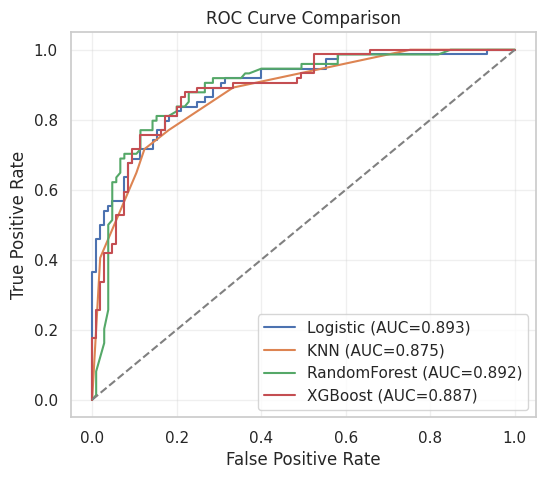

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic,0.798883,0.779412,0.716216,0.746479
1,KNN,0.810056,0.803030,0.716216,0.757143
2,RandomForest,0.826816,0.802817,0.770270,0.786207
3,XGBoost,0.821229,0.769231,0.810811,0.789474


In [ ]:
# Pipelines for each model
pipelines = {
    'Logistic': Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    'KNN': Pipeline([
        ('prep', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=7))
    ]),
    'RandomForest': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(random_state=42, n_estimators=100))
    ]),
    'XGBoost': Pipeline([
        ('prep', preprocessor),
        ('model', XGBClassifier(
            random_state=42,
            n_estimators=500,
            learning_rate=0.1,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='binary:logistic',
            tree_method='hist',
            n_jobs=-1,
            eval_metric='logloss'
        ))
    ])
}

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(train_df_model, y, test_size=0.2, random_state=42)

# Evaluate each model
results = []
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    results.append([name, acc, prec, rec, f1])

    print(f"\n=== {name} ===")
    print(confusion_matrix(y_val, y_pred))
    print(classification_report(y_val, y_pred, target_names=["Not Survived", "Survived"]))

# ROC curve comparison
plt.figure(figsize=(6,5))
for name, pipe in pipelines.items():
    y_prob = pipe.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Summary table
df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
df_results


# 6) Hyperparameter Tuning & Predicition

In [ ]:
RANDOM_STATE = 42

# Random Forest model
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Wrap RF with preprocessing so it works on the raw Titanic data
rf_pipe = Pipeline([
    ('prep', preprocessor),   # ColumnTransformer from before
    ('model', rf)
])

# Hyperparameter search space
param_dist = {
    'model__n_estimators': [200, 400, 600, 800],
    'model__max_depth': [None, 10, 20, 30, 40],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['auto', 'sqrt', 'log2']
}

# Cross-validation
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# RandomizedSearchCV
rand_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist,
    n_iter=20,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# Fit model
rand_search.fit(X_train, y_train)

# Results
print("Best parameters:", rand_search.best_params_)
print("Best CV Accuracy:", rand_search.best_score_)

# Retrain best RF on all data
best_model = rand_search.best_estimator_
best_model.fit(train_df_model, y)

# Predict
kaggle_preds = best_model.predict(test_df_model)

# Create submission file
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'].values,
    'Survived': kaggle_preds
})
submission.to_csv('submission.csv', index=False)
submission.head()

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20}
Best CV Accuracy: 0.8118048907326644


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


# Final Reflection

Our final model was a Random Forest Classifier, tuned using RandomizedSearchCV with cross-validation. After hyperparameter optimization, the best configuration included a relatively high number of estimators and balanced depth constraints, which allowed the model to generalize well without overfitting. This tuned Random Forest achieved strong performance on the validation set, and when submitted to Kaggle, it produced a competitive score that aligned with our expectations based on cross-validation accuracy.

The most challenging part of the project was balancing preprocessing choices with model flexibility. The Titanic dataset is small but messy, with missing values in Age, Embarked, and Fare. Deciding how to impute these values while avoiding data leakage required careful thought. Additionally, encoding categorical variables in a way that preserved interpretability while remaining compatible with tree-based models was a subtle but important step.

From the EDA phase, the most surprising discovery was the magnitude of survival differences by sex and class. Women had a survival rate of ~74% compared to ~19% for men, and first-class passengers had a survival rate of ~63% compared to ~24% for third-class passengers. These stark contrasts highlighted how social and economic factors strongly influenced survival outcomes, which was both historically interesting and practically useful for feature engineering.


The preprocessing and feature engineering choices that had the biggest impact were the creation of FamilySize and IsAlone features, as well as binning Age and Fare. These transformations captured non-linear relationships and interactions that raw variables alone could not. For example, small families (2–3 members) had higher survival rates than solo travelers or very large families, which the model leveraged effectively.
The Modeling Lead learned that while Logistic Regression provided a baseline and KNN struggled with scaling issues, tree-based models (Random Forest, XGBoost) consistently outperformed others. Random Forest offered robustness and interpretability, while XGBoost provided slightly higher validation scores but required more careful tuning. Ultimately, Random Forest was chosen for its balance of performance, simplicity, and stability. If we had another week, we would explore ensemble methods (stacking Logistic Regression, Random Forest, and XGBoost), perform feature importance analysis to refine the feature set, and experiment with advanced imputation techniques (such as iterative imputation or model-based imputation). We would also consider incorporating external data (like passenger titles from names) to enrich the feature space further.
